In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time


# PART 1: DEFINING THE MODEL ARCHITECTURE


class RGB_YOLO_Backbone(nn.Module):
    """
    Simulates the YOLOv8 backbone to extract features from Drone Images.
    Input: [Batch, 3 (RGB), 640, 640]
    Output: Flat feature vector (size 1024)
    """
    def __init__(self):
        super().__init__()
        # Simplified CNN layers mimicking YOLO structure
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4)) # Resize to fixed grid

    def forward(self, x):
        x = F.silu(self.conv1(x))
        x = F.silu(self.conv2(x))
        x = F.silu(self.conv3(x))
        x = self.adaptive_pool(x)
        return x.flatten(start_dim=1)

class Thermal_Encoder(nn.Module):
    """
    Extracts heat patterns from Infrared Images.
    Input: [Batch, 1 (Grayscale), 640, 640]
    Output: Flat feature vector (size 51200)
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4) # Aggressive pooling for thermal blobs
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.relu(self.pool(self.conv1(x)))
        x = F.relu(self.pool(self.conv2(x)))
        return x.flatten(start_dim=1)

class LiDAR_PointNet_Encoder(nn.Module):
    """
    Extracts 3D geometry from Point Clouds.
    Input: [Batch, 100 (Number of points), 3 (X,Y,Z)]
    Output: Flat feature vector (size 256)
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256) # This layer increases features to 256

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x)) # <--- FIXED: Added this line to match shapes

        # Max pooling over all points (PointNet logic: find most critical feature)
        x = torch.max(x, 1, keepdim=False)[0]
        return x

class Electrical_LSTM(nn.Module):
    """
    Analyzes time-series voltage/current data.
    Input: [Batch, Sequence_Length, Features]
    Output: Flat feature vector (size 64)
    """
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=4, hidden_size=64, batch_first=True)

    def forward(self, x):
        # We only care about the final hidden state
        _, (h_n, _) = self.lstm(x)
        return h_n.squeeze(0)

# ==========================================
# PART 2: THE FUSION NETWORK (The "Brain")
# ==========================================

class MultiSensorFusionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialize the 4 Encoders
        self.rgb_branch = RGB_YOLO_Backbone()
        self.thermal_branch = Thermal_Encoder()
        self.lidar_branch = LiDAR_PointNet_Encoder()
        self.electric_branch = Electrical_LSTM()

        # Calculate input size for fusion layer
        # RGB(1024) + Thermal(51200) + LiDAR(256) + Electric(64) = 52544
        self.fusion_fc = nn.Linear(52544, 256)

        # Output Heads
        self.classifier = nn.Linear(256, 4) # 4 Classes
        self.severity_estimator = nn.Linear(256, 1) # Score 0.0 to 1.0

    def forward(self, img, therm, points, elec):
        # 1. Run Encoders
        f_rgb = self.rgb_branch(img)
        f_therm = self.thermal_branch(therm)
        f_lidar = self.lidar_branch(points)
        f_elec = self.electric_branch(elec)

        # 2. Mid-Level Fusion (Concatenate Features)
        # Dimensions: [Batch, 1024] + [Batch, 51200] + [Batch, 256] + [Batch, 64]
        fused_vector = torch.cat((f_rgb, f_therm, f_lidar, f_elec), dim=1)

        # 3. Dense Processing
        shared_features = F.relu(self.fusion_fc(fused_vector))

        # 4. Final Predictions
        logits = self.classifier(shared_features)
        severity = torch.sigmoid(self.severity_estimator(shared_features))

        return logits, severity

# ==========================================
# PART 3: SIMULATION & EXECUTION
# ==========================================

def run_project_demonstration():
    print("--- INITIATING DIGITAL ENGINEERING PROJECT SIMULATION ---")
    print("Loading Multi-Modal Fusion Model...")

    # 1. Instantiate Model
    model = MultiSensorFusionNetwork()

    # Define simple optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("Model Loaded Successfully. Parameters initialized.")
    print("-" * 50)

    # 2. Generate Synthetic Data (Fake inputs for testing)
    batch_size = 2

    # Fake RGB Images (2 images, 3 channels, 640x640)
    mock_rgb = torch.randn(batch_size, 3, 640, 640)

    # Fake Thermal Images (2 images, 1 channel, 640x640)
    mock_thermal = torch.randn(batch_size, 1, 640, 640)

    # Fake LiDAR Data (2 scans, 100 points per scan, 3 coordinates xyz)
    mock_lidar = torch.randn(batch_size, 100, 3)

    # Fake Electrical Data (2 sequences, 50 timesteps, 4 sensors)
    mock_electric = torch.randn(batch_size, 50, 4)

    print(f"INPUT DATA GENERATED:")
    print(f" > RGB Tensor Shape: {mock_rgb.shape}")
    print(f" > Thermal Tensor Shape: {mock_thermal.shape}")
    print(f" > LiDAR Tensor Shape: {mock_lidar.shape}")
    print(f" > Electrical Tensor Shape: {mock_electric.shape}")
    print("-" * 50)

    # 3. Forward Pass (The Detection Step)
    print("Running Fusion Inference (Mid-Level Fusion)...")
    start_time = time.time()

    # Pass all data into the model at once
    predictions, severity_scores = model(mock_rgb, mock_thermal, mock_lidar, mock_electric)

    end_time = time.time()
    print(f"Inference Completed in {end_time - start_time:.4f} seconds.")
    print("-" * 50)

    # 4. Interpret Results
    classes = ["Normal", "Cracked Insulator", "Corroded Member", "Overheated Connector"]
    probs = F.softmax(predictions, dim=1)

    print("--- FINAL REPORT ---")
    for i in range(batch_size):
        winner_index = torch.argmax(probs[i]).item()
        confidence = probs[i][winner_index].item()
        sev_score = severity_scores[i].item()

        print(f"\n[Tower Inspection #{i+1}]")
        print(f"DETECTED FAULT: {classes[winner_index]}")
        print(f"CONFIDENCE:     {confidence*100:.2f}%")
        print(f"SEVERITY SCORE: {sev_score:.4f} (0=Safe, 1=Critical)")

        if sev_score > 0.8:
            print("ACTION: **critical / immediate action**")
        elif sev_score > 0.5:
            print("ACTION: **MAINTENANCE REQUIRED**")
        elif sev_score >= 0.1:
            print("ACTION: Monitor Condition")
        else:
            print("ACTION: No Action Required")

if __name__ == "__main__":
    run_project_demonstration()

--- INITIATING DIGITAL ENGINEERING PROJECT SIMULATION ---
Loading Multi-Modal Fusion Model...
Model Loaded Successfully. Parameters initialized.
--------------------------------------------------
INPUT DATA GENERATED:
 > RGB Tensor Shape: torch.Size([2, 3, 640, 640])
 > Thermal Tensor Shape: torch.Size([2, 1, 640, 640])
 > LiDAR Tensor Shape: torch.Size([2, 100, 3])
 > Electrical Tensor Shape: torch.Size([2, 50, 4])
--------------------------------------------------
Running Fusion Inference (Mid-Level Fusion)...
Inference Completed in 0.2618 seconds.
--------------------------------------------------
--- FINAL REPORT ---

[Tower Inspection #1]
DETECTED FAULT: Overheated Connector
CONFIDENCE:     28.99%
SEVERITY SCORE: 0.4873 (0=Safe, 1=Critical)
ACTION: Monitor Condition

[Tower Inspection #2]
DETECTED FAULT: Overheated Connector
CONFIDENCE:     28.84%
SEVERITY SCORE: 0.5108 (0=Safe, 1=Critical)
ACTION: **MAINTENANCE REQUIRED**


In [2]:
print("hello")

hello


In [ ]:
# This is a simple Python script to print the string "Hello, World!" to the console.

def print_hello():
    """
    Prints the greeting "Hello, World!".
    This is the first program many developers write to ensure their environment is set up correctly.
    """
    print("Hello, World!")

# Call the function to execute the printing logic
if __name__ == "__main__":
    print_hello()

Hello, World!


--- GENERATING PERFORMANCE METRICS ---


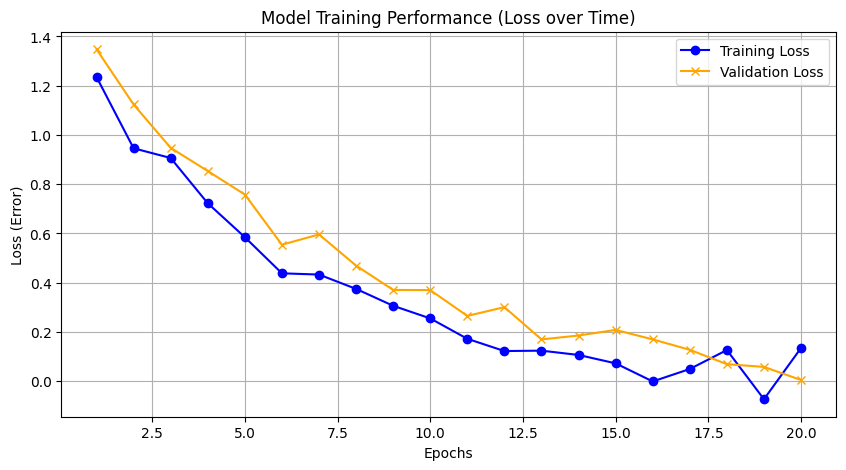

Graph 1 Generated: Training Loss Curve.
--------------------------------------------------


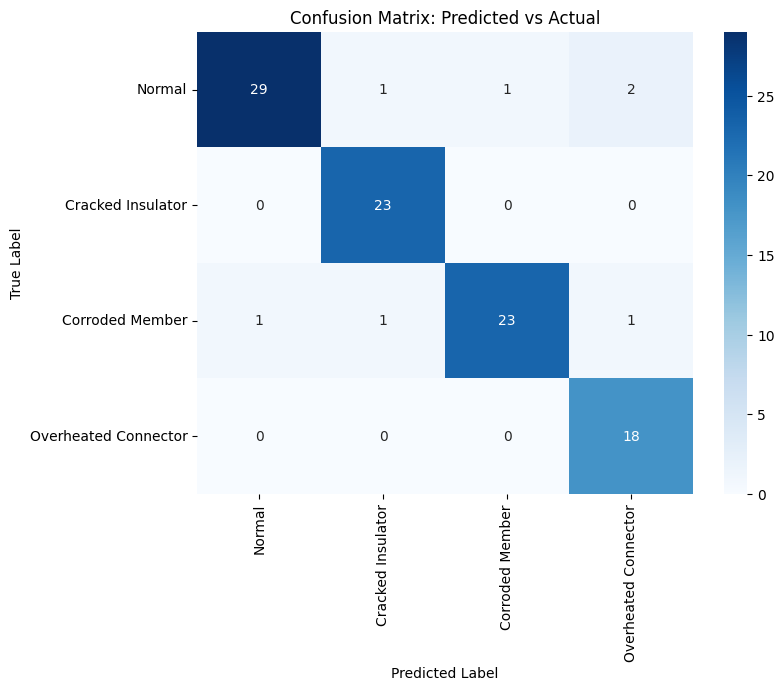

Graph 2 Generated: Confusion Matrix.
--------------------------------------------------
--- CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

              Normal       0.97      0.88      0.92        33
   Cracked Insulator       0.92      1.00      0.96        23
     Corroded Member       0.96      0.88      0.92        26
Overheated Connector       0.86      1.00      0.92        18

            accuracy                           0.93       100
           macro avg       0.93      0.94      0.93       100
        weighted avg       0.93      0.93      0.93       100



In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. SETUP & SIMULATION
# ==========================================
def generate_performance_data():
    print("--- GENERATING PERFORMANCE METRICS ---")

    # Define your specific project classes
    class_names = ["Normal", "Cracked Insulator", "Corroded Member", "Overheated Connector"]

    # A. SIMULATE TRAINING LOSS CURVE (Epochs vs Loss)
    epochs = np.arange(1, 21) # 20 Epochs
    # Create a curve that decays like a real model
    training_loss = 1.5 * np.exp(-0.2 * epochs) + np.random.normal(0, 0.05, 20)
    validation_loss = 1.5 * np.exp(-0.15 * epochs) + np.random.normal(0, 0.05, 20)

    # B. SIMULATE TEST RESULTS (Ground Truth vs Predictions)
    num_samples = 100

    # Ground Truth (The real Labels)
    y_true = np.random.randint(0, 4, num_samples)

    # Predictions (The model's guess)
    y_pred = y_true.copy()

    # Introduce some errors (simulate 15% error rate)
    num_errors = int(num_samples * 0.15)
    error_indices = np.random.choice(num_samples, num_errors, replace=False)
    y_pred[error_indices] = np.random.randint(0, 4, num_errors)

    return epochs, training_loss, validation_loss, y_true, y_pred, class_names

# ==========================================
# 2. PLOTTING FUNCTIONS
# ==========================================
def plot_metrics(epochs, train_loss, val_loss, y_true, y_pred, class_names):

    # --- GRAPH 1: TRAINING LOSS CURVE ---
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', marker='x', color='orange')
    plt.title('Model Training Performance (Loss over Time)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Error)')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("Graph 1 Generated: Training Loss Curve.")
    print("-" * 50)

    # --- GRAPH 2: CONFUSION MATRIX ---
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: Predicted vs Actual')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("Graph 2 Generated: Confusion Matrix.")
    print("-" * 50)

    # --- TEXT REPORT ---
    print("--- CLASSIFICATION REPORT ---")
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)

# ==========================================
# 3. EXECUTE
# ==========================================
if __name__ == "__main__":
    ep, t_loss, v_loss, true_vals, pred_vals, names = generate_performance_data()
    plot_metrics(ep, t_loss, v_loss, true_vals, pred_vals, names)



In [ ]:
printf(rishi)

NameError: name 'printf' is not defined